In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))

In [2]:
# Standard library imports
import sys
from pathlib import Path

# Third-party scientific computing
import pandas as pd

# Deep learning frameworks

# Visualization

# Machine learning
from sklearn.pipeline import Pipeline

# Local imports - data processing
from src.data_models.caravanify import Caravanify, CaravanifyConfig
from src.data_models.datamodule import HydroDataModule
from src.preprocessing.grouped import GroupedTransformer
from src.preprocessing.standard_scale import StandardScaleTransformer
from src.preprocessing.log_scale import LogTransformer

# Local imports - models and evaluation
from src.models.dummy import RepeatLastValuesConfig, LitRepeatLastValues

from src.models.tft import TFTConfig, LitTFT
from src.models.ealstm import EALSTMConfig, LitEALSTM
from src.models.tide import TiDEConfig, LitTiDE
from src.models.tsmixer import TSMixerConfig, LitTSMixer
from src.model_evaluation.evaluators import TSForecastEvaluator
from src.model_evaluation.visualization import (
    plot_metric_boxplot,
    plot_rolling_forecast,
    plot_metric_cdf
)
from src.model_evaluation.hp_from_yaml import hp_from_yaml

---

In [3]:
STATIC_FEATURES = [
    "gauge_id",
    "p_mean",
    "area",
    "ele_mt_sav",
    "high_prec_dur",
    "frac_snow",
    "high_prec_freq",
    "slp_dg_sav",
    "cly_pc_sav",
    "aridity_ERA5_LAND",
    "aridity_FAO_PM",
]

FORCING_FEATURES = [
    "snow_depth_water_equivalent_mean",
    "surface_net_solar_radiation_mean",
    "surface_net_thermal_radiation_mean",
    "potential_evaporation_sum_ERA5_LAND",
    "potential_evaporation_sum_FAO_PENMAN_MONTEITH",
    "temperature_2m_mean",
    "temperature_2m_min",
    "temperature_2m_max",
    "total_precipitation_sum",
]

TARGET = "streamflow"

In [4]:
# Either Kyrgyzstan or Tajikistan or combined
COUNTRY = "Kyrgyzstan"

In [5]:
ealstm_yaml = f"/Users/cooper/Desktop/CAMELS-CH/experiments/SimilarityBasedTransfer/yaml_files/{COUNTRY.lower()}/ealstm.yaml"
tft_yaml = f"/Users/cooper/Desktop/CAMELS-CH/experiments/SimilarityBasedTransfer/yaml_files/{COUNTRY.lower()}/tft.yaml"
tide_yaml = f"/Users/cooper/Desktop/CAMELS-CH/experiments/SimilarityBasedTransfer/yaml_files/{COUNTRY.lower()}/tide.yaml"
tsmixer_yaml = f"/Users/cooper/Desktop/CAMELS-CH/experiments/SimilarityBasedTransfer/yaml_files/{COUNTRY.lower()}/tsmixer.yaml"


tft_hp = hp_from_yaml("tft", tft_yaml)
tide_hp = hp_from_yaml("tide", tide_yaml)
ealstm_hp = hp_from_yaml("ealstm", ealstm_yaml)
tsmixer_hp = hp_from_yaml("tsmixer", tsmixer_yaml)

In [6]:
TFT_config = TFTConfig(**tft_hp)
EALSTM_config = EALSTMConfig(**ealstm_hp)
TiDE_config = TiDEConfig(**tide_hp)
TSMixer_config = TSMixerConfig(**tsmixer_hp)

dummy_config = RepeatLastValuesConfig(
    input_len=tide_hp["input_len"],
    input_size=tide_hp["input_size"],
    output_len=tide_hp["output_len"],
)

---

In [7]:
config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/shapefiles",
    # human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

ca_caravan = Caravanify(config)
ca_basins = ca_caravan.get_all_gauge_ids()
# ca_basins = [bid for bid in ca_basins if bid not in ["CA_17110", "CA_17329"]]

print(f"Found {len(ca_basins)} total CA basins")

ca_caravan.load_stations(ca_basins)

# Prepare data frames
ts_columns = FORCING_FEATURES + [TARGET]
static_columns = STATIC_FEATURES

ca_ts_data = ca_caravan.get_time_series()[ts_columns + ["date"] + ["gauge_id"]]
ca_static_data = ca_caravan.get_static_attributes()[static_columns + ["country"]]

Found 78 total CA basins


In [8]:
# ids for the COUUNTRY

country_ids = ca_static_data[ca_static_data["country"] == COUNTRY]["gauge_id"].unique()

ca_ts_data = ca_ts_data[ca_ts_data["gauge_id"].isin(country_ids)]
ca_static_data = ca_static_data[ca_static_data["gauge_id"].isin(country_ids)]

print(f"Found {len(country_ids)} total CA basins in {COUNTRY}")

Found 62 total CA basins in Kyrgyzstan


---

In [9]:
# Use GroupedTransformer for both features and target
feature_pipeline = Pipeline([("scaler", StandardScaleTransformer())])

target_pipeline = GroupedTransformer(
    Pipeline([("log", LogTransformer()), ("scaler", StandardScaleTransformer())]),
    columns=[TARGET],
    group_identifier="gauge_id",
    n_jobs=-1,
)


static_pipeline = Pipeline([("scaler", StandardScaleTransformer())])
preprocessing_config = {
    "features": {"pipeline": feature_pipeline},
    "target": {"pipeline": target_pipeline},
    "static_features": {"pipeline": static_pipeline},
}

In [10]:
STATIC_FEATURES = [col for col in static_columns]
FORCING_FEATURES = FORCING_FEATURES + [TARGET]

tft_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=tft_hp["input_len"],
    output_length=tft_hp["output_len"],
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

ealstm_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=ealstm_hp["input_len"],
    output_length=ealstm_hp["output_len"],
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

tide_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=tide_hp["input_len"],
    output_length=tide_hp["output_len"],
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

tsmixer_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=tsmixer_hp["input_len"],
    output_length=tsmixer_hp["output_len"],
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

In [11]:
if COUNTRY == "Tajikistan":
    ealstm_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/tajikistan/ealstm/run_0/Tajikistan_ealstm_epoch=33_val_loss=0.0549.ckpt"
    tide_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/tajikistan/tide/run_0/Tajikistan_tide_epoch=46_val_loss=0.0616.ckpt"
    tsmixer_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/tajikistan/tsmixer/run_0/Tajikistan_tsmixer_epoch=60_val_loss=0.0571.ckpt"
    tft_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/tajikistan/tft/run_0/Tajikistan_tft_epoch=48_val_loss=0.0527.ckpt"

elif COUNTRY == "Kyrgyzstan":
    ealstm_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/kyrgyzstan/ealstm/run_0/Kyrgyzstan_ealstm_epoch=16_val_loss=0.0534.ckpt"
    tide_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/kyrgyzstan/tide/run_0/Kyrgyzstan_tide_epoch=15_val_loss=0.0558.ckpt"
    tsmixer_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/kyrgyzstan/tsmixer/run_0/Kyrgyzstan_tsmixer_epoch=12_val_loss=0.0547.ckpt"
    tft_benchmark_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/Benchmark/output/checkpoints/kyrgyzstan/tft/run_0/Kyrgyzstan_tft_epoch=20_val_loss=0.0534.ckpt"


In [12]:
if COUNTRY == "Tajikistan":
    ealstm_hii_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints/tajikistan/ealstm/Tajikistan_ealstm_epoch=09_val_loss=0.0494.ckpt"
    tide_hii_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints/tajikistan/tide/Tajikistan_tide_epoch=11_val_loss=0.0512.ckpt"
    tsmixer_hii_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints/tajikistan/tsmixer/Tajikistan_tsmixer_epoch=23_val_loss=0.0473.ckpt"
    tft_hii_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints/tajikistan/tft/Tajikistan_tft_epoch=13_val_loss=0.0470.ckpt"
    ealstm_similarity_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints/tajikistan/ealstm/Tajikistan_ealstm_epoch=07_val_loss=0.0488.ckpt"
    tide_similarity_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints/tajikistan/tide/Tajikistan_tide_epoch=13_val_loss=0.0486.ckpt"
    tsmixer_similarity_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints/tajikistan/tsmixer/Tajikistan_tsmixer_epoch=09_val_loss=0.0476.ckpt"
    tft_similarity_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints/tajikistan/tft/Tajikistan_tft_epoch=08_val_loss=0.0486.ckpt"


elif COUNTRY == "Kyrgyzstan":
    ealstm_hii_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints/kyrgyzstan/ealstm/Kyrgyzstan_ealstm_epoch=02_val_loss=0.0563.ckpt"
    tide_hii_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints/kyrgyzstan/tide/Kyrgyzstan_tide_epoch=06_val_loss=0.0545.ckpt"
    tsmixer_hii_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints/kyrgyzstan/tsmixer/Kyrgyzstan_tsmixer_epoch=06_val_loss=0.0549.ckpt"
    tft_hii_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/LowHumanInfluenceTransfer/checkpoints/kyrgyzstan/tft/Kyrgyzstan_tft_epoch=10_val_loss=0.0541.ckpt"
    ealstm_similarity_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints/kyrgyzstan/ealstm/Kyrgyzstan_ealstm_epoch=03_val_loss=0.0586.ckpt"
    tide_similarity_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints/kyrgyzstan/tide/Kyrgyzstan_tide_epoch=05_val_loss=0.0546.ckpt"
    tsmixer_similarity_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints/kyrgyzstan/tsmixer/Kyrgyzstan_tsmixer_epoch=05_val_loss=0.0553.ckpt"
    tft_similarity_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/FineTuning/output/SimilarityBased/checkpoints/kyrgyzstan/tft/Kyrgyzstan_tft_epoch=06_val_loss=0.0547.ckpt"

In [13]:
dummy_model = LitRepeatLastValues(config=dummy_config)
tft_benchmark_model = LitTFT.load_from_checkpoint(tft_benchmark_ckpt, config=TFT_config)
ealstm_benchmark_model = LitEALSTM.load_from_checkpoint(
    ealstm_benchmark_ckpt, config=EALSTM_config
)
tide_benchmark_model = LitTiDE.load_from_checkpoint(
    tide_benchmark_ckpt, config=TiDE_config
)
tsmixer_benchmark_model = LitTSMixer.load_from_checkpoint(
    tsmixer_benchmark_ckpt, config=TSMixer_config
)
tft_hii_model = LitTFT.load_from_checkpoint(tft_hii_ckpt, config=TFT_config)
ealstm_hii_model = LitEALSTM.load_from_checkpoint(ealstm_hii_ckpt, config=EALSTM_config)
tide_hii_model = LitTiDE.load_from_checkpoint(tide_hii_ckpt, config=TiDE_config)
tsmixer_hii_model = LitTSMixer.load_from_checkpoint(
    tsmixer_hii_ckpt, config=TSMixer_config
)
tft_similarity_model = LitTFT.load_from_checkpoint(
    tft_similarity_ckpt, config=TFT_config
)
ealstm_similarity_model = LitEALSTM.load_from_checkpoint(
    ealstm_similarity_ckpt, config=EALSTM_config
)
tide_similarity_model = LitTiDE.load_from_checkpoint(
    tide_similarity_ckpt, config=TiDE_config
)
tsmixer_similarity_model = LitTSMixer.load_from_checkpoint(
    tsmixer_similarity_ckpt, config=TSMixer_config
)


# Create a dictionary mapping model names to (model, datamodule) tuples
models_and_datamodules = {
    "dummy": (dummy_model, tide_data_module),
    "tft_benchmark": (tft_benchmark_model, tft_data_module),
    "tft_hii": (tft_hii_model, tft_data_module),
    "tft_similarity": (tft_similarity_model, tft_data_module),
    "ealstm_benchmark": (ealstm_benchmark_model, ealstm_data_module),
    "ealstm_hii": (ealstm_hii_model, ealstm_data_module),
    "ealstm_similarity": (ealstm_similarity_model, ealstm_data_module),
    "tide_benchmark": (tide_benchmark_model, tide_data_module),
    "tide_hii": (tide_hii_model, tide_data_module),
    "tide_similarity": (tide_similarity_model, tide_data_module),
    "tsmixer_benchmark": (tsmixer_benchmark_model, tsmixer_data_module),
    "tsmixer_hii": (tsmixer_hii_model, tsmixer_data_module),
    "tsmixer_similarity": (tsmixer_similarity_model, tsmixer_data_module),
}


evaluator = TSForecastEvaluator(
    horizons=list(range(1, 11)),
    models_and_datamodules=models_and_datamodules,
    trainer_kwargs={"accelerator": "gpu", "devices": 1},
)

/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.5.1, which is newer than your current Lightning version: v2.5.0.post0


In [14]:
# Run evaluation
results = evaluator.test_models()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Testing dummy...
Original basins: 62
Retained basins: 61
Domain CA (source): Created 105285 valid sequences from 61 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.09220851212739944
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Evaluating results with shape: preds=(105285, 10), obs=(105285, 10), basin_ids=(105285,)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.06572756916284561
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Evaluating results with shape: preds=(103028, 10), obs=(103028, 10), basin_ids=(103028,)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Testing tsmixer_similarity...
Original basins: 62
Retained basins: 61
Domain CA (source): Created 103028 valid sequences from 61 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.07229691743850708
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Evaluating results with shape: preds=(103028, 10), obs=(103028, 10), basin_ids=(103028,)


In [15]:
def filter_growing_season(eval_results):
    """
    Filter evaluation results to include only data from the growing season (April to October).

    Args:
        eval_results: Dictionary containing evaluation results with a 'df' key

    Returns:
        Dictionary with filtered dataframe and original metrics
    """
    # Create a copy of the results to avoid modifying the original
    filtered_results = eval_results.copy()

    # Extract the dataframe
    df = eval_results["df"].copy()

    # Ensure date column is datetime
    df["date"] = pd.to_datetime(df["date"])

    # Filter for growing season (April to October)
    growing_season_df = df[(df["date"].dt.month >= 4) & (df["date"].dt.month < 10)]

    # Replace the dataframe in the results
    filtered_results["df"] = growing_season_df

    return filtered_results


seasonal_dummy_results = filter_growing_season(results["dummy"])
seasonal_tide_benchmark_results = filter_growing_season(results["tide_benchmark"])
seasonal_ealstm_benchmark_results = filter_growing_season(results["ealstm_benchmark"])
seasonal_tsmixer_benchmark_results = filter_growing_season(results["tsmixer_benchmark"])
seasonal_tft_benchmark_results = filter_growing_season(results["tft_benchmark"])
seasonal_tide_hii_results = filter_growing_season(results["tide_hii"])
seasonal_ealstm_hii_results = filter_growing_season(results["ealstm_hii"])
seasonal_tsmixer_hii_results = filter_growing_season(
    results["tsmixer_hii"]
)
seasonal_tft_similarity_results = filter_growing_season(results["tft_similarity"])
seasonal_tide_similarity_results = filter_growing_season(results["tide_similarity"])
seasonal_ealstm_similarity_results = filter_growing_season(results["ealstm_similarity"])
seasonal_tsmixer_similarity_results = filter_growing_season(
    results["tsmixer_similarity"]
)
seasonal_tft_hii_results = filter_growing_season(results["tft_hii"])



seasonal_dummy_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_dummy_results["df"]
)
seasonal_tide_benchmark_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_tide_benchmark_results["df"]
)
seasonal_ealstm_benchmark_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_ealstm_benchmark_results["df"]
)

seasonal_tsmixer_benchmark_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_tsmixer_benchmark_results["df"]
)
seasonal_tft_benchmark_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_tft_benchmark_results["df"]
)
seasonal_tide_hii_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_tide_hii_results["df"]
)
seasonal_ealstm_hii_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_ealstm_hii_results["df"]
)
seasonal_tsmixer_hii_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_tsmixer_hii_results["df"]
)
seasonal_tft_hii_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_tft_hii_results["df"]
)
seasonal_tide_similarity_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_tide_similarity_results["df"]
)
seasonal_ealstm_similarity_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_ealstm_similarity_results["df"]
)
seasonal_tsmixer_similarity_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_tsmixer_similarity_results["df"]
)
seasonal_tft_similarity_results["metrics"] = evaluator._calculate_overall_metrics(
    seasonal_tft_similarity_results["df"]
)


seasonal_dummy_results["basin_metrics"] = evaluator._calculate_basin_metrics(
    seasonal_dummy_results["df"]
)
seasonal_tide_benchmark_results["basin_metrics"] = evaluator._calculate_basin_metrics(
    seasonal_tide_benchmark_results["df"]
)

seasonal_ealstm_benchmark_results["basin_metrics"] = evaluator._calculate_basin_metrics(
    seasonal_ealstm_benchmark_results["df"]
)

seasonal_tsmixer_benchmark_results["basin_metrics"] = (
    evaluator._calculate_basin_metrics(seasonal_tsmixer_benchmark_results["df"])
)

seasonal_tft_benchmark_results["basin_metrics"] = evaluator._calculate_basin_metrics(
    seasonal_tft_benchmark_results["df"]
)
seasonal_tide_hii_results["basin_metrics"] = evaluator._calculate_basin_metrics(
    seasonal_tide_hii_results["df"]
)
seasonal_ealstm_hii_results["basin_metrics"] = (
    evaluator._calculate_basin_metrics(seasonal_ealstm_hii_results["df"])
)
seasonal_tsmixer_hii_results["basin_metrics"] = (
    evaluator._calculate_basin_metrics(seasonal_tsmixer_hii_results["df"])
)
seasonal_tft_hii_results["basin_metrics"] = evaluator._calculate_basin_metrics(
    seasonal_tft_hii_results["df"]
)
seasonal_tide_similarity_results["basin_metrics"] = evaluator._calculate_basin_metrics(
    seasonal_tide_similarity_results["df"]
)
seasonal_ealstm_similarity_results["basin_metrics"] = (
    evaluator._calculate_basin_metrics(seasonal_ealstm_similarity_results["df"])
)
seasonal_tsmixer_similarity_results["basin_metrics"] = (
    evaluator._calculate_basin_metrics(seasonal_tsmixer_similarity_results["df"])
)
seasonal_tft_similarity_results["basin_metrics"] = evaluator._calculate_basin_metrics(
    seasonal_tft_similarity_results["df"]
)


seasonal_results = {}

seasonal_results["dummy"] = seasonal_dummy_results
seasonal_results["tide_benchmark"] = seasonal_tide_benchmark_results
seasonal_results["ealstm_benchmark"] = seasonal_ealstm_benchmark_results
seasonal_results["tsmixer_benchmark"] = seasonal_tsmixer_benchmark_results
seasonal_results["tft_benchmark"] = seasonal_tft_benchmark_results
seasonal_results["tide_hii"] = seasonal_tide_hii_results
seasonal_results["ealstm_hii"] = seasonal_ealstm_hii_results
seasonal_results["tsmixer_hii"] = seasonal_tsmixer_hii_results
seasonal_results["tft_hii"] = seasonal_tft_hii_results
seasonal_results["tide_similarity"] = seasonal_tide_similarity_results
seasonal_results["ealstm_similarity"] = seasonal_ealstm_similarity_results
seasonal_results["tsmixer_similarity"] = seasonal_tsmixer_similarity_results
seasonal_results["tft_similarity"] = seasonal_tft_similarity_results

In [16]:
from typing import List, Optional
import matplotlib.pyplot as plt
import seaborn as sns

def generate_color_triplets(
    num_triplets: int,
    base_palette: Optional[str] = "husl",
    lightness_factor_1: float = 0.5,
    lightness_factor_2: float = 0.8,
) -> List[str]:
    # Get base colors from seaborn
    base_colors = sns.color_palette(base_palette, n_colors=num_triplets)

    # Create two lighter versions of each color with different lightness factors
    medium_colors = []
    light_colors = []
    
    for rgb in base_colors:
        # Convert to medium version
        medium_rgb = tuple(c + (1 - c) * lightness_factor_1 for c in rgb)
        medium_colors.append(medium_rgb)
        
        # Convert to lighter version
        light_rgb = tuple(c + (1 - c) * lightness_factor_2 for c in rgb)
        light_colors.append(light_rgb)

    # Combine base, medium, and light variants to create triplets
    color_triplets = []
    for base, medium, light in zip(base_colors, medium_colors, light_colors):
        color_triplets.extend([base, medium, light])

    return color_triplets

In [17]:
sns.set_context(context="paper", font_scale=1.2)

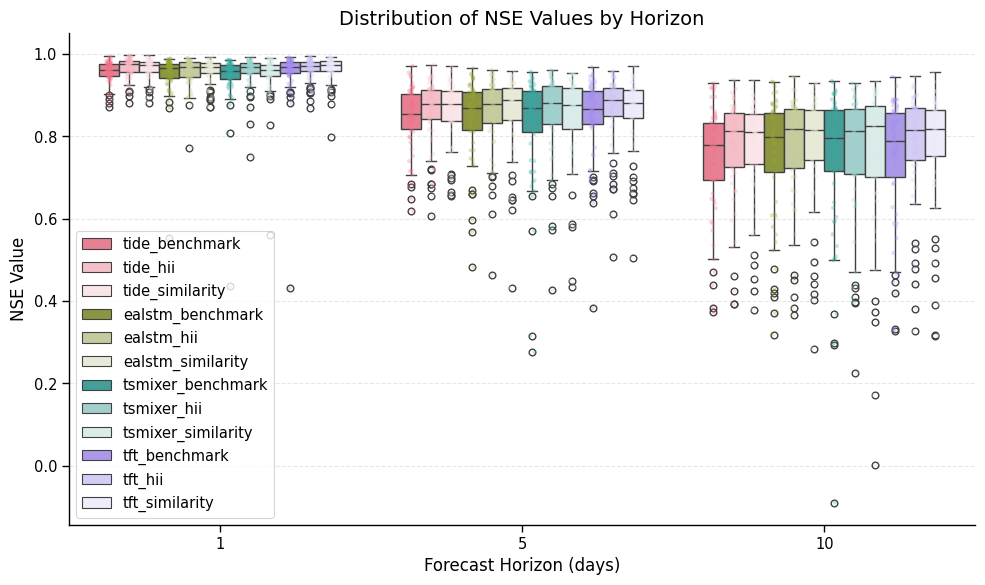

In [18]:
palette = generate_color_triplets(4)


fig, ax = plot_metric_boxplot(
    seasonal_results,
    [
        "tide_benchmark",
        "tide_hii",
        "tide_similarity",
        "ealstm_benchmark",
        "ealstm_hii",
        "ealstm_similarity",
        "tsmixer_benchmark",
        "tsmixer_hii",
        "tsmixer_similarity",
        "tft_benchmark",
        "tft_hii",
        "tft_similarity",

    ],
    metric="NSE",
    individual_points=True,
    palette=palette,
    horizons=[1, 5, 10],
    fig_size=(10, 6),
)

plt.legend(loc="lower left")

path_to_save = f"/Users/cooper/Desktop/CAMELS-CH/images/global_summary_boxplots_all_models_{COUNTRY}.png"
fig.savefig(path_to_save, dpi=300, bbox_inches="tight")